Name : Nisha Pragane | Rollno:13 | PRN :1252090013| DIV :SEDA| Batch:B1

11.Assignment on Classification technique. Every year many students give the GRE exam to get admission in foreign Universities. The data set contains GRE Scores (out of 340), TOEFL Scores (out of 120), University Rating (out of 5), Statement of Purpose strength (out of 5), Letter of Recommendation strength (out of 5), Undergraduate GPA (out of 10), Research Experience (0=no, 1=yes), Admitted (0=no, 1=yes). Admitted is the target variable.
Data Set: https://www.kaggle.com/mohansacharya/graduate-admissions
The counsellor of the firm is supposed check whether the student will get an admission or not based on his/her GRE score and Academic Score. So to help the counsellor to make appropriate decisions, build a machine learning model classifier using a Decision tree to predict whether a student will get admission or not.  Apply Data pre-processing (Label Encoding, Data Transformation….) techniques if necessary.
Perform data-preparation (Train-Test Split)
Apply Machine Learning Algorithm
Evaluate Model.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Load dataset

In [11]:
df = pd.read_csv('Admission_Predict.csv')
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


Data Preprocessing

In [12]:
if 'Serial No.' in df.columns:
    df = df.drop(columns=['Serial No.'])
    df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GRE Score          400 non-null    int64  
 1   TOEFL Score        400 non-null    int64  
 2   University Rating  400 non-null    int64  
 3   SOP                400 non-null    float64
 4   LOR                400 non-null    float64
 5   CGPA               400 non-null    float64
 6   Research           400 non-null    int64  
 7   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 25.1 KB


Convert Target Variable

In [17]:
if 'Chance of Admit ' in df.columns:
    df['Admitted'] = df['Chance of Admit '].apply(lambda x: 1 if x >= 0.75 else 0)
    df = df.drop(columns=['Chance of Admit '])
    df.head()

Feature Selection

In [18]:
X = df[['GRE Score',
        'TOEFL Score',
        'University Rating',
        'SOP',
        'LOR ',
        'CGPA',
        'Research']]
y = df['Admitted']

Train-Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (320, 7)
Testing size: (80, 7)


Decision Tree Algorithm

In [20]:
model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    random_state=42
)
model.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

Predictions

In [21]:
y_pred=model.predict(X_test)

Evaluate Model

In [22]:
accuracy =accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.9375


Confusion Matrix

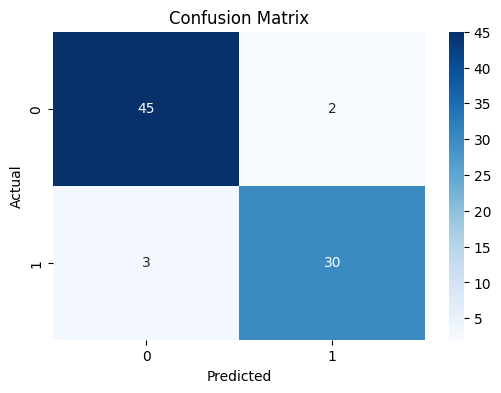

In [23]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Classification Report

In [24]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95        47
           1       0.94      0.91      0.92        33

    accuracy                           0.94        80
   macro avg       0.94      0.93      0.94        80
weighted avg       0.94      0.94      0.94        80



Visualize Decision Tree

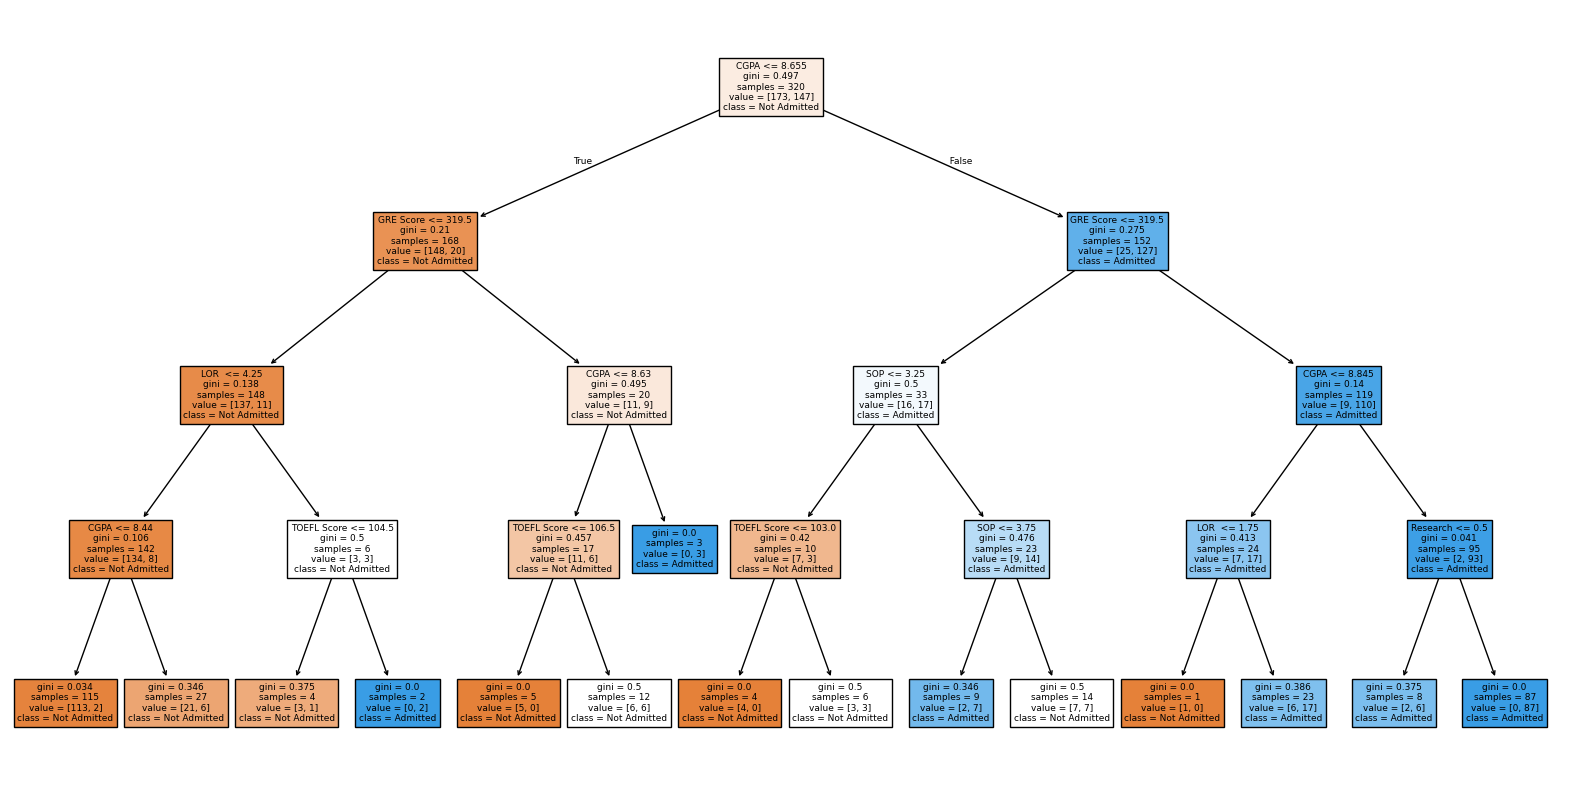

In [25]:
plt.figure(figsize=(20,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Not Admitted','Admitted'],
    filled=True
)
plt.show()

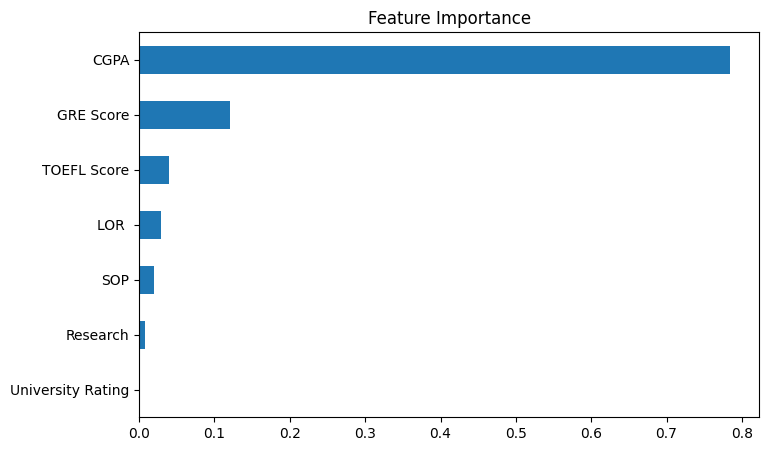

In [26]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)
importance.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)
plt.title("Feature Importance")
plt.show()